# DATA 37100 — Final Project Analysis
**Student:** Ben Bentley  
**Date:** March 2026

## Research Question
**How do diffusion timesteps (T) and prediction target (eps vs x0) affect sample sharpness and failure modes on MNIST?**

## Model Coverage
- **Baseline 1:** Diffusion (MNIST)
- **Baseline 2:** DCGAN (MNIST)
- **Controlled Experiment:** Diffusion two-knob grid (T and target)

## 1. Setup

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set paths relative to repo root
REPO_ROOT = Path('.').resolve().parent.parent  # Go up from final/draft/ to repo root
DIFF_OUT = REPO_ROOT / 'untrack/outputs/final/diffusion'
GAN_OUT = REPO_ROOT / 'untrack/outputs/final/gan'

print(f"Diffusion outputs: {DIFF_OUT}")
print(f"GAN outputs: {GAN_OUT}")

Diffusion outputs: /Users/benbentley/Documents/School/UChicago/Winter 2026/Intro to AI Deep Learning and Generative AI/BenBentley_Final_DATA37100/untrack/outputs/final/diffusion
GAN outputs: /Users/benbentley/Documents/School/UChicago/Winter 2026/Intro to AI Deep Learning and Generative AI/BenBentley_Final_DATA37100/untrack/outputs/final/gan


## 2. Baseline Results

### 2.1 Diffusion Baseline (T=200, eps target)

In [2]:
# Load diffusion baseline summary
diff_baseline_dirs = sorted([d for d in DIFF_OUT.glob('*') if d.is_dir() and 'T-200' in d.name])
if diff_baseline_dirs:
    diff_baseline = diff_baseline_dirs[0]
    diff_summary = json.loads((diff_baseline / 'summary.json').read_text())
    diff_args = json.loads((diff_baseline / 'run_args.json').read_text())
    
    print("Diffusion Baseline Configuration:")
    print(f"  T: {diff_args.get('T')}")
    print(f"  target: {diff_args.get('target')}")
    print(f"  base_ch: {diff_args.get('base_ch')}")
    print(f"  Runtime: {diff_summary.get('seconds', 0):.1f}s")
    print(f"  Device: {diff_summary.get('device')}")
else:
    print("Run baselines first: bash final/deliverables/run_baselines.sh")

Diffusion Baseline Configuration:
  T: 200
  target: eps
  base_ch: 64
  Runtime: 51.5s
  Device: mps


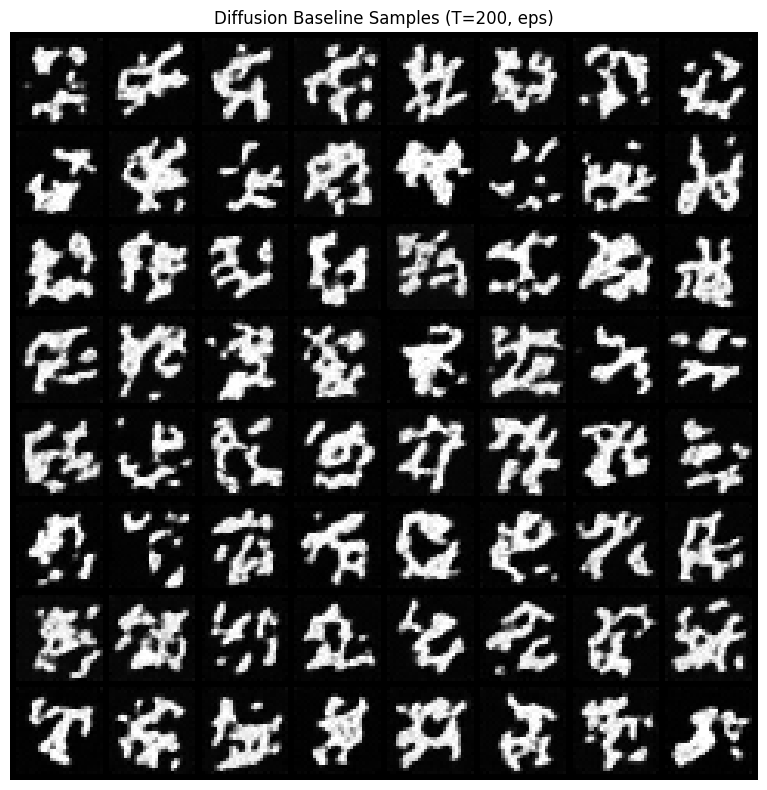

In [3]:
# Display diffusion baseline samples
if diff_baseline_dirs:
    sample_imgs = sorted((diff_baseline / 'samples').glob('*.png'))
    if sample_imgs:
        # Use the last sample (final step)
        img = mpimg.imread(str(sample_imgs[-1]))
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title(f"Diffusion Baseline Samples (T={diff_args.get('T')}, {diff_args.get('target')})")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

### 2.2 DCGAN Baseline

In [4]:
# Load GAN baseline summary
diff_baseline_dirs = sorted([d for d in DIFF_OUT.glob('*') if d.is_dir() and 'T-200' in d.name])
gan_baseline_dirs = sorted([d for d in GAN_OUT.glob('*') if d.is_dir()])
if gan_baseline_dirs:
    gan_baseline = gan_baseline_dirs[0]
    gan_args = json.loads((gan_baseline / 'run_args.json').read_text())
    
    # GAN uses train_log.csv instead of summary.json
    train_log_path = gan_baseline / 'train_log.csv'
    train_log = pd.read_csv(train_log_path) if train_log_path.exists() else None
    
    print("DCGAN Baseline Configuration:")
    print(f"  max_steps: {gan_args.get('max_steps')}")
    print(f"  lr: {gan_args.get('lr')}")
    print(f"  base_ch: {gan_args.get('base_ch')}")
    print(f"  z_dim: {gan_args.get('z_dim')}")
    if train_log is not None:
        print(f"  Training steps: {len(train_log)}")
    print(f"  Device: {gan_args.get('device', 'N/A')}")

DCGAN Baseline Configuration:
  max_steps: 400
  lr: 0.0002
  base_ch: 64
  z_dim: 128
  Training steps: 400
  Device: auto


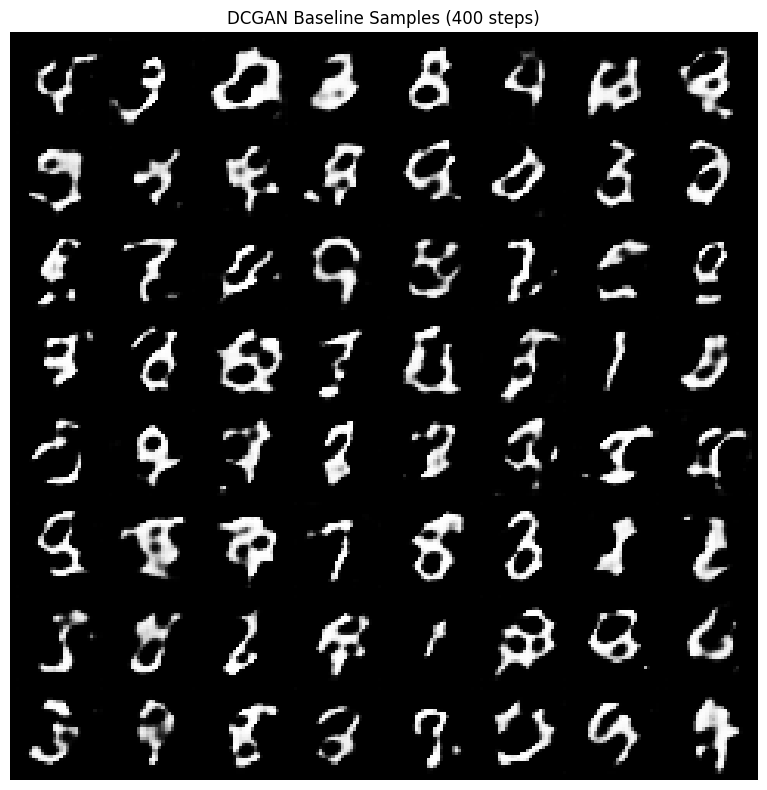

In [5]:
# Display GAN baseline samples
if gan_baseline_dirs:
    sample_imgs = sorted((gan_baseline / 'samples').glob('*.png'))
    if sample_imgs:
        # Use the last sample (final step)
        img = mpimg.imread(str(sample_imgs[-1]))
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title(f"DCGAN Baseline Samples ({gan_args.get('max_steps')} steps)")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

## 3. Controlled Experiment: T × target Grid

**Experimental Design:**
- **Knob 1:** T (diffusion timesteps) ∈ {100, 200, 400}
- **Knob 2:** target (prediction parameterization) ∈ {eps, x0}
- **Total runs:** 6
- **Control variables:** base_ch=64, seed=42, dataset=MNIST, epochs=1

In [6]:
# Load experiment results
results_csv = DIFF_OUT / 'results.csv'
if results_csv.exists():
    df = pd.read_csv(results_csv)
    print(f"Loaded {len(df)} experiment runs")
    display(df[['run_dir']].head(10))
else:
    print("Run experiment first: bash final/draft/run_experiment.sh")
    df = None

Loaded 6 experiment runs


,run_dir
0,untrack/outputs/final/diffusion/ds-mnist_T-100...
1,untrack/outputs/final/diffusion/ds-mnist_T-100...
2,untrack/outputs/final/diffusion/ds-mnist_T-200...
3,untrack/outputs/final/diffusion/ds-mnist_T-200...
4,untrack/outputs/final/diffusion/ds-mnist_T-400...
5,untrack/outputs/final/diffusion/ds-mnist_T-400...


In [7]:
# Extract run parameters and metrics
if df is not None:
    def read_json(p: Path):
        return json.loads(p.read_text(encoding='utf-8'))

    rows = []
    for rd in df['run_dir']:
        rd = Path(rd)
        if not rd.is_absolute():
            rd = REPO_ROOT / rd
        args = read_json(rd / 'run_args.json') if (rd / 'run_args.json').exists() else {}
        summ = read_json(rd / 'summary.json') if (rd / 'summary.json').exists() else {}
        
        row = {
            'run_name': rd.name,
            'T': args.get('T'),
            'target': args.get('target'),
            'base_ch': args.get('base_ch'),
            'runtime_sec': summ.get('seconds', 0),
            'device': summ.get('device'),
        }
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    print("\nExperiment Summary:")
    display(summary_df)
    
    # Runtime statistics
    print(f"\nAverage runtime: {summary_df['runtime_sec'].mean():.1f}s")
    print(f"Total runtime: {summary_df['runtime_sec'].sum():.1f}s")


Experiment Summary:


,run_name,T,target,base_ch,runtime_sec,device
0,ds-mnist_T-100_target-eps_b2-0.02_ch-64,100,eps,64,48.13,mps
1,ds-mnist_T-100_target-x0_b2-0.02_ch-64,100,x0,64,47.55,mps
2,ds-mnist_T-200_target-eps_b2-0.02_ch-64,200,eps,64,51.47,mps
3,ds-mnist_T-200_target-x0_b2-0.02_ch-64,200,x0,64,51.44,mps
4,ds-mnist_T-400_target-eps_b2-0.02_ch-64,400,eps,64,59.52,mps
5,ds-mnist_T-400_target-x0_b2-0.02_ch-64,400,x0,64,59.41,mps



Average runtime: 52.9s
Total runtime: 317.5s


### 3.0 Auto Summary

This helper cell prints the actual `T`, `target`, and runtime values used in Section 3.

In [8]:
# Auto-summary for Section 3 values
if df is not None:
    def latest_sample_png(run_dir: Path):
        samples_dir = run_dir / 'samples'
        final_samples = sorted(samples_dir.glob('samples_step*.png'))
        if final_samples:
            return final_samples[-1]
        grid_samples = sorted(samples_dir.glob('grid_step*.png'))
        if grid_samples:
            return grid_samples[-1]
        return None

    metric_rows = []
    for _, row in summary_df.iterrows():
        run_dir = DIFF_OUT / row['run_name']
        sample_png = latest_sample_png(run_dir)
        metric_rows.append({
            'run_name': row['run_name'],
            'sample_file': sample_png.name if sample_png is not None else None,
        })

    experiment_df = summary_df.merge(pd.DataFrame(metric_rows), on='run_name', how='left')
    experiment_df = experiment_df.sort_values(['T', 'target']).reset_index(drop=True)
    experiment_df = experiment_df.drop_duplicates(subset=['T', 'target'], keep='last')

    print('Section 3 experiment values:')
    display(experiment_df[['T', 'target', 'runtime_sec', 'device', 'sample_file']])

    print('\nRuntime pivot (seconds):')
    display(experiment_df.pivot_table(index='T', columns='target', values='runtime_sec', aggfunc='first').round(2))


Section 3 experiment values:


,T,target,runtime_sec,device,sample_file
0,100,eps,48.13,mps,samples_step000468.png
1,100,x0,47.55,mps,samples_step000468.png
2,200,eps,51.47,mps,samples_step000468.png
3,200,x0,51.44,mps,samples_step000468.png
4,400,eps,59.52,mps,samples_step000468.png
5,400,x0,59.41,mps,samples_step000468.png



Runtime pivot (seconds):


target,eps,x0
T,,
100,48.13,47.55
200,51.47,51.44
400,59.52,59.41


### 3.1 Visual Comparison Grid

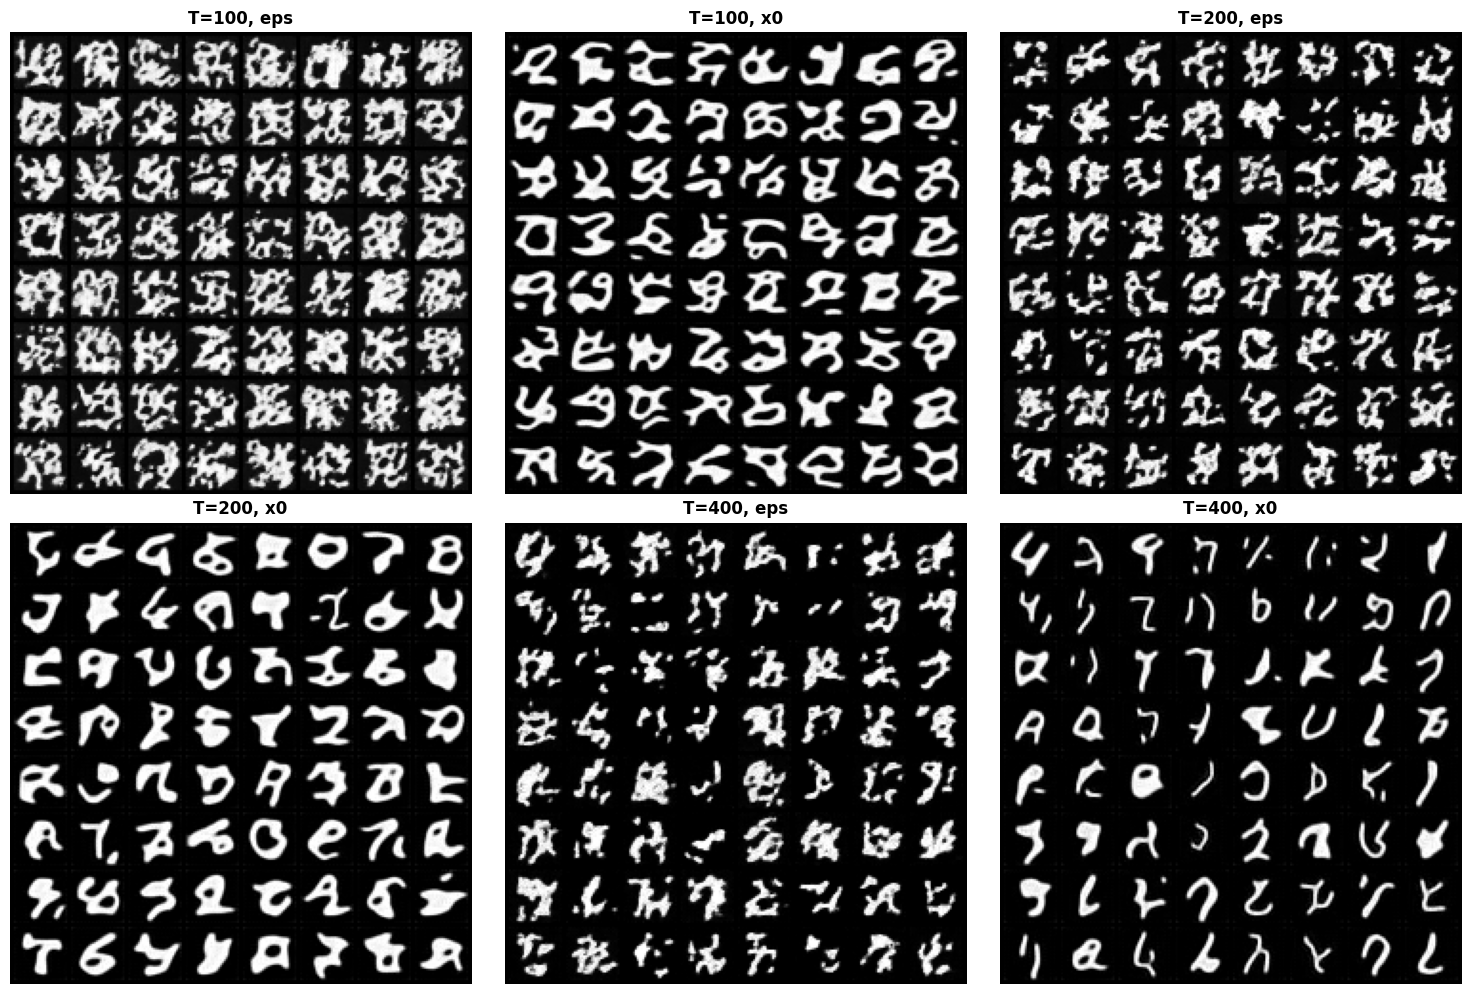

In [9]:
# Create side-by-side comparison of all experiment runs
if df is not None:
    def find_pngs(run_dir: Path):
        samples_dir = run_dir / 'samples'
        final_samples = sorted(samples_dir.glob('samples_step*.png'))
        if final_samples:
            return [final_samples[-1]]
        grid_samples = sorted(samples_dir.glob('grid_step*.png'))
        if grid_samples:
            return [grid_samples[-1]]
        candidates = sorted(run_dir.glob('*.png'))
        return candidates[-1:] if candidates else []

    imgs = []
    titles = []
    for _, row in summary_df.iterrows():
        rd = DIFF_OUT / row['run_name']
        pngs = find_pngs(rd)
        if pngs:
            imgs.append(pngs[0])
            titles.append(f"T={row['T']}, {row['target']}")

    n = len(imgs)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    
    plt.figure(figsize=(5*ncols, 5*nrows))
    for i, (p, t) in enumerate(zip(imgs, titles), start=1):
        ax = plt.subplot(nrows, ncols, i)
        ax.imshow(mpimg.imread(str(p)))
        ax.set_title(t, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### 3.2 Effect of T (Timesteps)

**Hypothesis:** More timesteps should produce sharper samples by allowing finer-grained noise removal.

**Observations:**
- As T increased, the image quality of the samples became sharper in general. As T increased, the runtime increased as well.
- At higher T, there are instances where the images lose interpretability. For example, in the last sample (T=400, x0), the last three images on the first row are essentially scribble and are not interpretable. 
- There is likely a sweet spot in the trade off between higher T, runtime, and interpretablity of the samples generated. 

### 3.3 Effect of target (eps vs x0)

**Background:** 
- `eps` predicts noise to remove
- `x0` predicts the clean image directly

**Hypothesis:** `x0` may produce sharper early samples but struggle with stability; `eps` may be more stable but slower to sharpen.

**Observations:**
- x0 generated sharper and more interpretable sample images. 
- eps generated sample images with more grain and more static. 
- In general, x0 took longer to run but in effect the runtimes are virtually the same.
- eps generated more stable images, but would likely take longer to produce interpretable results. x0 produced cleaner images more quickly, but started to destablize on certain sample images by T = 400. 

### 3.4 Interaction Effects

**Question:** Does the effect of T depend on the target parameterization?

**Observations:**
- Increasing T produces cleaner results for both eps and x0. Higher T produces cleaner sample for eps and refines the digits and makes them more interpretable for x0. 

## 4. Failure Modes 

### 4.1 Mode Collapse (DCGAN)

**Evidence:**
- There is a lack of diversity in the step 400 sample of DCGAN. 

**Likely Cause:**
- Adversarial training instability, generator may exploit discriminator weaknesses and generate only digits that "trick" the discriminator. 

---

### 4.2 Blurry Samples at Low T (Diffusion)

**Evidence:**
- In the T = 400 samples, the images were less blurry than they were at T = 100. As T increased, the samples became less blurry. 

**Likely Cause:**
- Insufficient denoising steps as the discrete approximation of continuous SDE is too coarse. With more steps, the approximation becomes more continuous and the samples become cleaner. 